In [39]:
import numpy as np
import pandas as pd
import graphviz
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
pd.set_option("display.width", 140)

In [40]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
from pathlib import Path

# SEU CAMINHO AQUI OU O CAMINHO DO GDRIVE
DATA = Path("SEU CAMINHO AQUI OU O CAMINHO DO GDRIVE") / "curitiba_daily.parquet"

df = pd.read_parquet(DATA)
df.head()

,date,tp_mm,ssrd_wm2,t2m,t2m_min,t2m_max,d2m,dpd,wind_speed,wind_const,...,dpd_lag3,d2m_lag3,tp_lag1,tp_lag2,tp_lag3,tp_sum7,tp_sum30,tp_sum90,day_sin,day_cos
0,1980-04-01,0.365138,164.091782,16.377014,13.584625,19.219391,13.565399,2.811615,3.557601,0.994403,...,3.034027,17.161407,0.217268,7.260312,11.626924,19.293314,131.553467,490.767595,0.999963,0.008583
1,1980-04-02,0.120771,179.277222,16.698456,13.498688,21.525055,13.814331,2.884125,2.316316,0.986427,...,1.404877,17.366211,0.365138,0.217268,7.260312,19.657897,131.718006,490.271959,0.999963,-0.008583
2,1980-04-03,1.311496,195.243958,17.726776,14.785553,22.519684,14.285675,3.441101,1.947963,0.971664,...,2.811615,13.565399,0.120771,0.365138,0.217268,19.744550,130.102940,490.289570,0.999668,-0.025748
3,1980-04-04,6.795540,148.697220,18.550293,15.958160,22.249176,16.062836,2.487457,1.714343,0.953920,...,2.884125,13.814331,1.311496,0.120771,0.365138,20.948981,131.405409,491.405149,0.999079,-0.042905
4,1980-04-05,2.635221,144.128891,19.203552,17.001373,23.068512,17.138489,2.065063,1.144617,0.389403,...,3.441101,14.285675,6.795540,1.311496,0.120771,27.697448,138.184545,498.187063,0.998195,-0.060049


In [42]:
from pathlib import Path

FIGDIR = Path("figuras")
FIGDIR.mkdir(exist_ok=True)

def salvar(nome, fig=None, dpi=200, fechar=False):
    """Salva a figura atual em PNG. Chame ANTES de plt.show()."""
    fig = fig or plt.gcf()
    fig.savefig(FIGDIR / f"{nome}.png", dpi=dpi,
                bbox_inches="tight", facecolor="white")
    print(f"salvo: {nome}.png")
    if fechar:
        plt.close(fig)

## Análise Exploratória

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16710 entries, 0 to 16709
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          16710 non-null  datetime64[ns]
 1   tp_mm         16710 non-null  float32       
 2   ssrd_wm2      16710 non-null  float32       
 3   t2m           16710 non-null  float32       
 4   t2m_min       16710 non-null  float32       
 5   t2m_max       16710 non-null  float32       
 6   d2m           16710 non-null  float32       
 7   dpd           16710 non-null  float32       
 8   wind_speed    16710 non-null  float32       
 9   wind_const    16710 non-null  float32       
 10  wind_dir_sin  16710 non-null  float32       
 11  wind_dir_cos  16710 non-null  float32       
 12  dpd_lag2      16710 non-null  float32       
 13  d2m_lag2      16710 non-null  float32       
 14  dpd_lag3      16710 non-null  float32       
 15  d2m_lag3      16710 non-null  float3

In [44]:
TARGET = "tp_mm"

# Colunas que nunca entram no modelo: o alvo, a data e as auxiliares de
# agrupamento criadas ao longo do notebook. Definido uma vez só, aqui.
AUX = {"date", "tp_mm", "ano", "mes", "doy", "mes_nome", "decada", "estacao"}

# preditores meteorológicos "de base" (t−1), sem lags nem acumulados
MET = ["ssrd_wm2", "t2m", "t2m_min", "t2m_max", "d2m", "dpd",
       "wind_speed", "wind_const"]

LAGS   = ["tp_lag1", "tp_lag2", "tp_lag3",
          "d2m_lag2", "d2m_lag3", "dpd_lag2", "dpd_lag3"]
ACUM   = ["tp_sum7", "tp_sum30", "tp_sum90"]
CICLO  = ["wind_dir_sin", "wind_dir_cos", "day_sin", "day_cos"]

# Fonte única das features: para trocar a rodada de treinamento, mude AQUI.
# Nenhuma célula abaixo redefine FEATURES.
FEATURES = MET + LAGS + ACUM + CICLO
print("FEATURES: " + str(len(FEATURES)))

FEATURES: 22


In [45]:
df = df.sort_values("date").reset_index(drop=True)

df["ano"] = df.date.dt.year
df["mes"] = df.date.dt.month
df["doy"] = df.date.dt.dayofyear

In [46]:
d = df["date"]
grade = pd.date_range(d.min(), d.max(), freq="D")

print("período      :", d.min().date(), "→", d.max().date())
print("n linhas     :", len(df), "| dias na grade:", len(grade))
print("duplicados   :", int(d.duplicated().sum()))
print("dias faltando:", len(grade.difference(d)))

faltando = grade.difference(d)
if len(faltando):
    buracos = pd.Series(1, index=faltando).resample("YE").sum()
    ax = sns.barplot(x=buracos.index.year, y=buracos.values, color="crimson")
    ax.set(title="dias ausentes por ano", xlabel="", ylabel="dias")
    plt.xticks(rotation=90); plt.tight_layout(); plt.show()

período      : 1980-04-01 → 2025-12-30
n linhas     : 16710 | dias na grade: 16710
duplicados   : 0
dias faltando: 0


In [47]:
print(df[MET].describe().T[["min", "mean", "max", "std"]].round(2))
print("ssrd médio:", round(float(df.ssrd_wm2.mean()), 1), "W/m²")

             min    mean     max    std
ssrd_wm2    9.08  175.87  382.72  75.55
t2m         2.85   17.10   26.00   3.67
t2m_min    -2.39   13.93   21.95   3.81
t2m_max     5.75   21.53   33.22   4.26
d2m        -3.99   14.29   21.45   3.76
dpd         0.10    2.81   16.19   1.54
wind_speed  0.63    2.32    7.76   0.81
wind_const  0.01    0.83    1.00   0.19
ssrd médio: 175.9 W/m²


In [48]:
checks = {
    "t2m_min <= t2m":     df.t2m_min <= df.t2m + 1e-3,
    "t2m <= t2m_max":     df.t2m <= df.t2m_max + 1e-3,
    "d2m <= t2m":         df.d2m <= df.t2m + 1e-3,
    "dpd == t2m - d2m":   np.isclose(df.dpd, df.t2m - df.d2m, atol=1e-2),
    "dpd >= 0":           df.dpd >= -1e-3,
    "tp_mm >= 0":         df.tp_mm >= 0,
    "ssrd >= 0":          df.ssrd_wm2 >= 0,
    "sin²+cos² == 1":     np.isclose(df.wind_dir_sin**2 + df.wind_dir_cos**2, 1, atol=1e-3),
    "wind_const ∈ [0,1]": df.wind_const.between(-1e-6, 1 + 1e-6),
    "wind_speed >= 0":    df.wind_speed >= 0,
}
res = (pd.DataFrame({"viol": {k: int((~v).sum()) for k, v in checks.items()}})
         .assign(pct_ok=lambda x: 100 * (1 - x.viol / len(df)))
         .sort_values("viol", ascending=False))
print("\n", res.round(4))


                     viol  pct_ok
t2m_min <= t2m         0   100.0
t2m <= t2m_max         0   100.0
d2m <= t2m             0   100.0
dpd == t2m - d2m       0   100.0
dpd >= 0               0   100.0
tp_mm >= 0             0   100.0
ssrd >= 0              0   100.0
sin²+cos² == 1         0   100.0
wind_const ∈ [0,1]     0   100.0
wind_speed >= 0        0   100.0


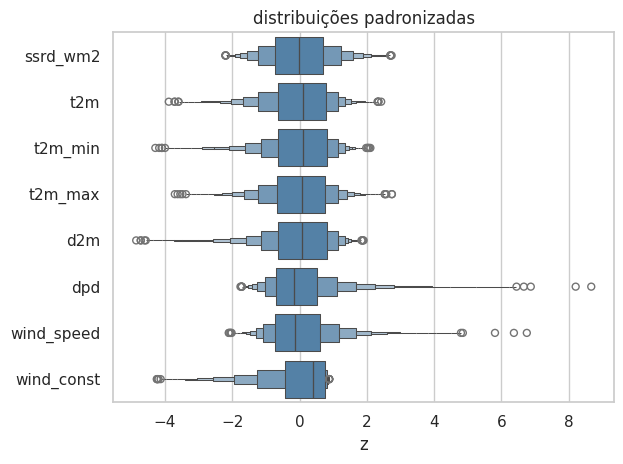

In [49]:
z = (df[MET] - df[MET].mean()) / df[MET].std()
ax = sns.boxenplot(data=z.melt(var_name="var", value_name="z"), x="z", y="var", color="steelblue")
ax.set(title="distribuições padronizadas", xlabel="z", ylabel="")
plt.tight_layout(); plt.show()


amplitude térmica: min 1.09 | mediana 7.44 | max 18.58
dias com amplitude < 1 °C: 0


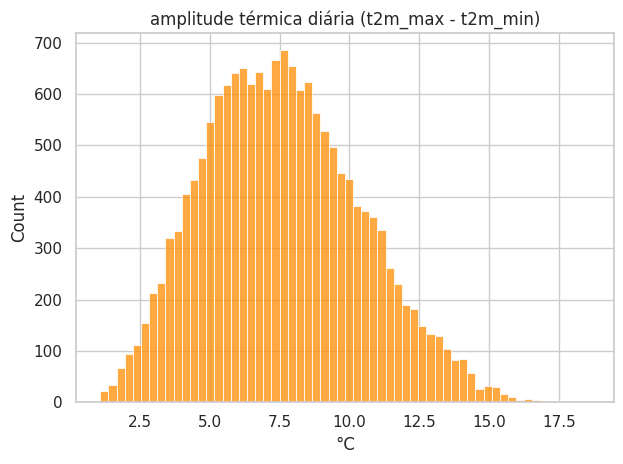

In [50]:
amp = df.t2m_max - df.t2m_min
print(f"\namplitude térmica: min {amp.min():.2f} | mediana {amp.median():.2f} | max {amp.max():.2f}")
print("dias com amplitude < 1 °C:", int((amp < 1).sum()))
ax = sns.histplot(amp, bins=60, color="darkorange")
ax.set(title="amplitude térmica diária (t2m_max - t2m_min)", xlabel="°C")
plt.tight_layout(); plt.show()

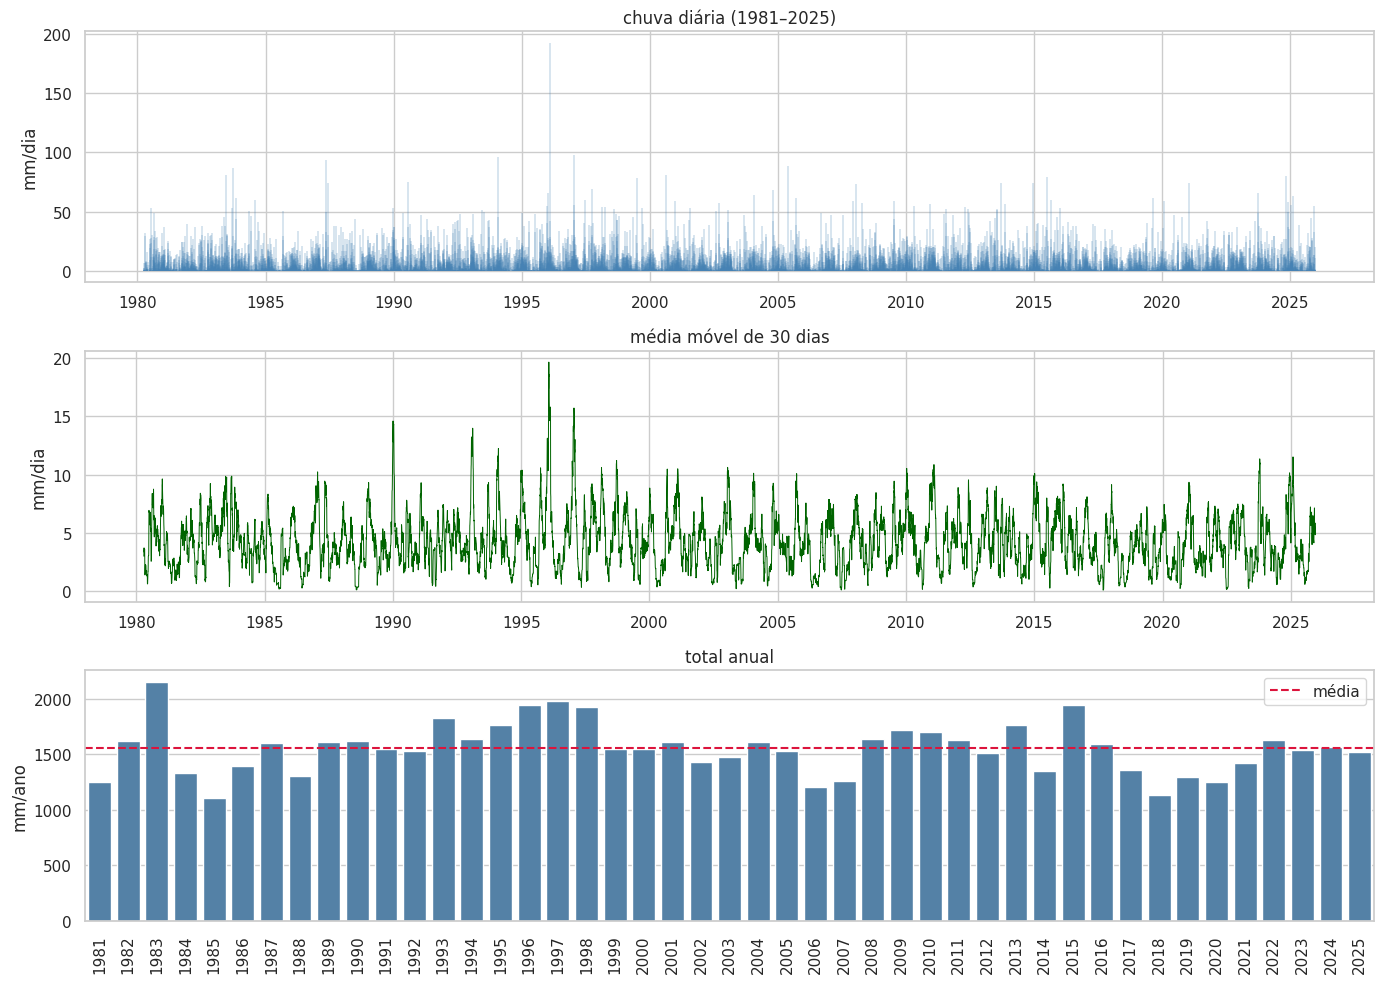

In [51]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 1. série diária bruta — mostra a densidade dos zeros e a altura dos extremos
axes[0].vlines(df.date, 0, df.tp_mm, lw=.3, color="steelblue")
axes[0].set(title="chuva diária (1981–2025)", ylabel="mm/dia", xlabel="")

# 2. média móvel de 30 dias — revela o ciclo sazonal e anos anômalos
sns.lineplot(x=df.date, y=df.tp_mm.rolling(30, center=True).mean(),
             ax=axes[1], lw=.7, color="darkgreen")
axes[1].set(title="média móvel de 30 dias", ylabel="mm/dia", xlabel="")

# 3. total anual + tendência
anual = df.groupby("ano").agg(total=("tp_mm", "sum"), n=("tp_mm", "size"))
anual = anual[anual.n > 360]
sns.barplot(x=anual.index, y=anual.total, ax=axes[2], color="steelblue")
axes[2].axhline(anual.total.mean(), color="crimson", ls="--", label="média")
axes[2].set(title="total anual", ylabel="mm/ano", xlabel="")
axes[2].tick_params(axis="x", rotation=90)
axes[2].legend()

plt.tight_layout(); plt.show()

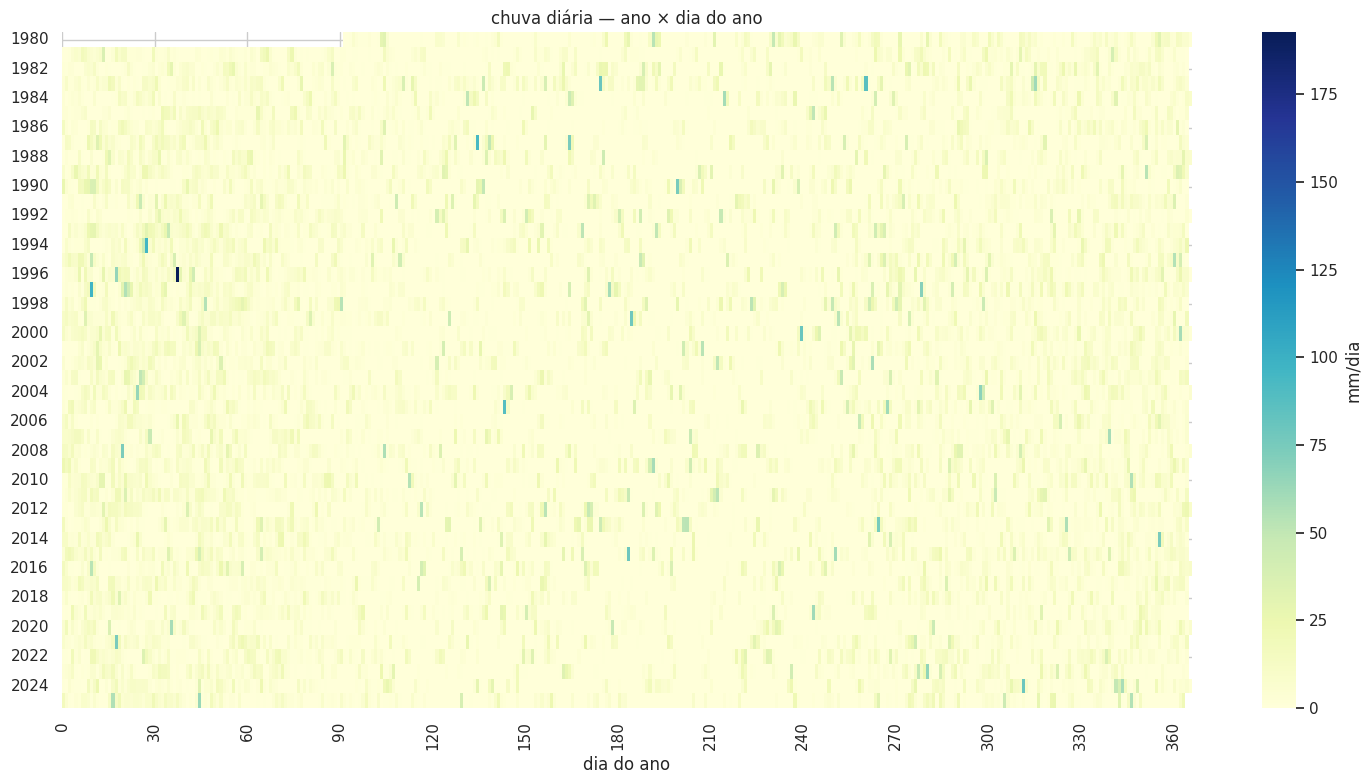

In [52]:
pivot = df.pivot_table(index="ano", columns="doy", values="tp_mm", aggfunc="mean")

fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(pivot, cmap="YlGnBu",
            cbar_kws={"label": "mm/dia"}, ax=ax)
ax.set(title="chuva diária — ano × dia do ano", xlabel="dia do ano", ylabel="")
ax.set_xticks(range(0, 366, 30)); ax.set_xticklabels(range(0, 366, 30))
plt.tight_layout(); plt.show()

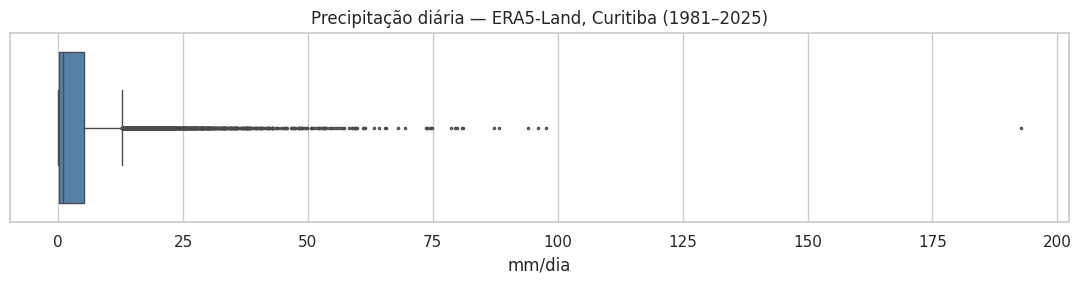

In [53]:
fig, ax = plt.subplots(figsize=(11, 3))
sns.boxplot(data=df, x="tp_mm", ax=ax, color="steelblue", fliersize=1.5)
ax.set(title="Precipitação diária — ERA5-Land, Curitiba (1981–2025)", xlabel="mm/dia")
plt.tight_layout(); plt.show()

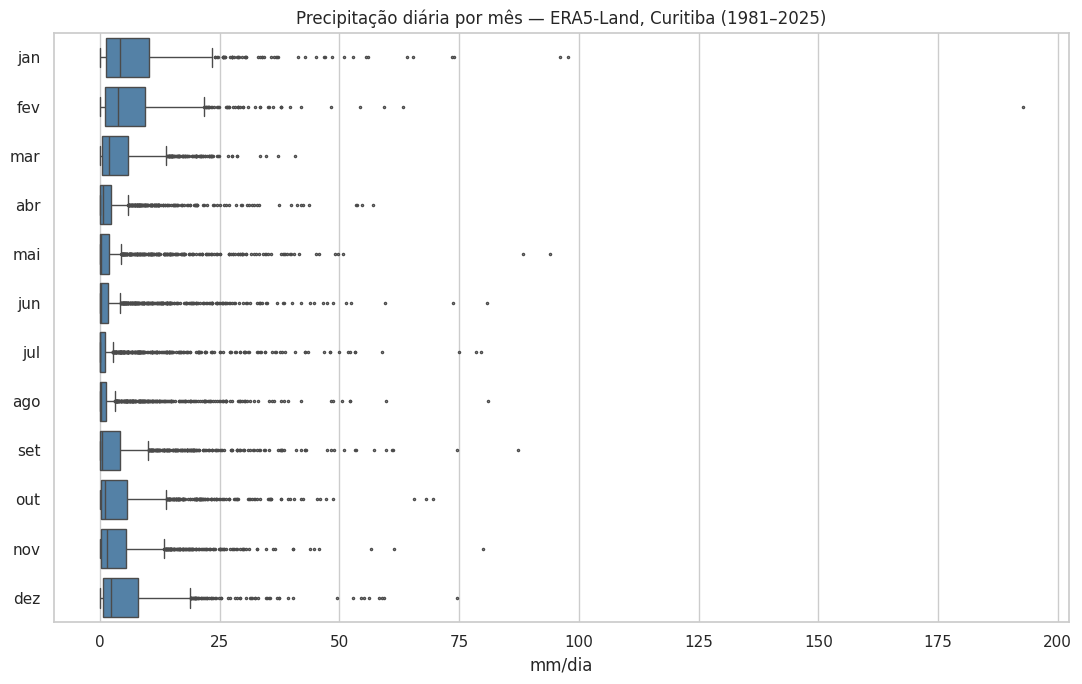

In [54]:
meses = ["jan", "fev", "mar", "abr", "mai", "jun",
         "jul", "ago", "set", "out", "nov", "dez"]

df["mes_nome"] = pd.Categorical(
    df.date.dt.month.map(dict(enumerate(meses, start=1))),
    categories=meses, ordered=True)

assert df.mes_nome.notna().all()   # pega qualquer mês perdido

fig, ax = plt.subplots(figsize=(11, 7))
sns.boxplot(data=df, y="mes_nome", x="tp_mm", ax=ax,
            color="steelblue", fliersize=1.5, orient="h")
ax.set(title="Precipitação diária por mês — ERA5-Land, Curitiba (1981–2025)",
       xlabel="mm/dia", ylabel="")
plt.tight_layout(); plt.show()

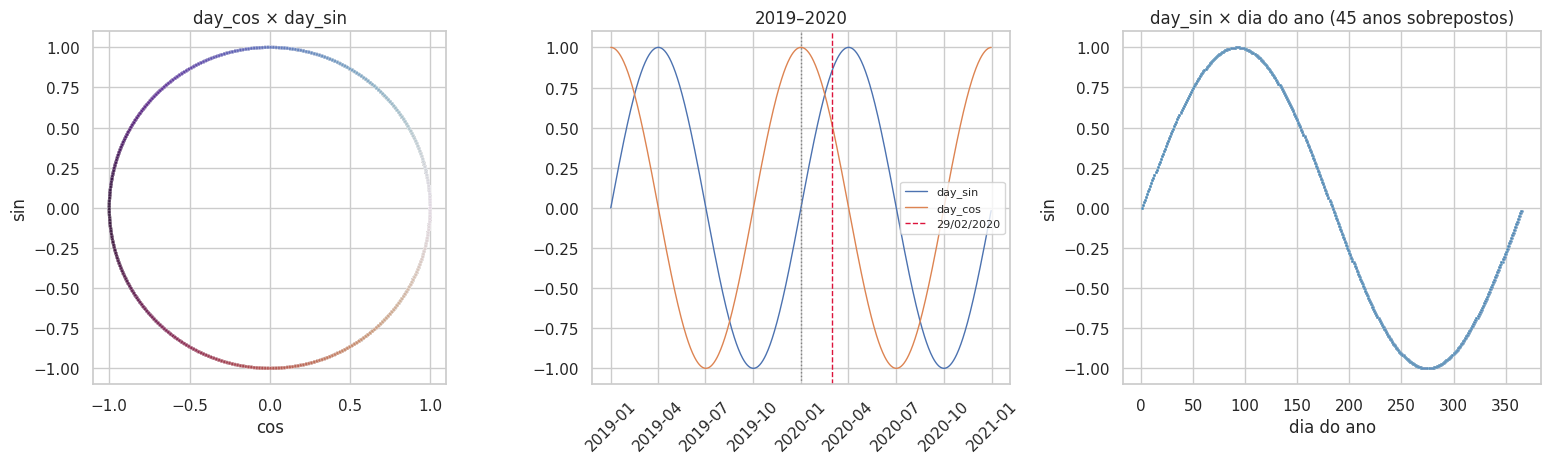

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# o círculo
sns.scatterplot(x=df.day_cos, y=df.day_sin, hue=df.doy, palette="twilight",
                s=5, alpha=.5, ax=axes[0], legend=False)
axes[0].set_aspect("equal")
axes[0].set(title="day_cos × day_sin", xlabel="cos", ylabel="sin")

# as duas ondas ao longo de dois anos, com um bissexto no meio
rec = df[df.ano.isin([2019, 2020])]
axes[1].plot(rec.date, rec.day_sin, lw=1, label="day_sin")
axes[1].plot(rec.date, rec.day_cos, lw=1, label="day_cos")
axes[1].axvline(pd.Timestamp("2020-02-29"), color="crimson", ls="--", lw=1, label="29/02/2020")
axes[1].axvline(pd.Timestamp("2020-01-01"), color="gray", ls=":", lw=1)
axes[1].set(title="2019–2020", xlabel="")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=45)

# sin contra o dia do ano, todos os 45 anos sobrepostos
sns.scatterplot(x=df.doy, y=df.day_sin, s=3, alpha=.15, ax=axes[2], color="steelblue")
axes[2].set(title="day_sin × dia do ano (45 anos sobrepostos)", xlabel="dia do ano", ylabel="sin")

plt.tight_layout(); plt.show()

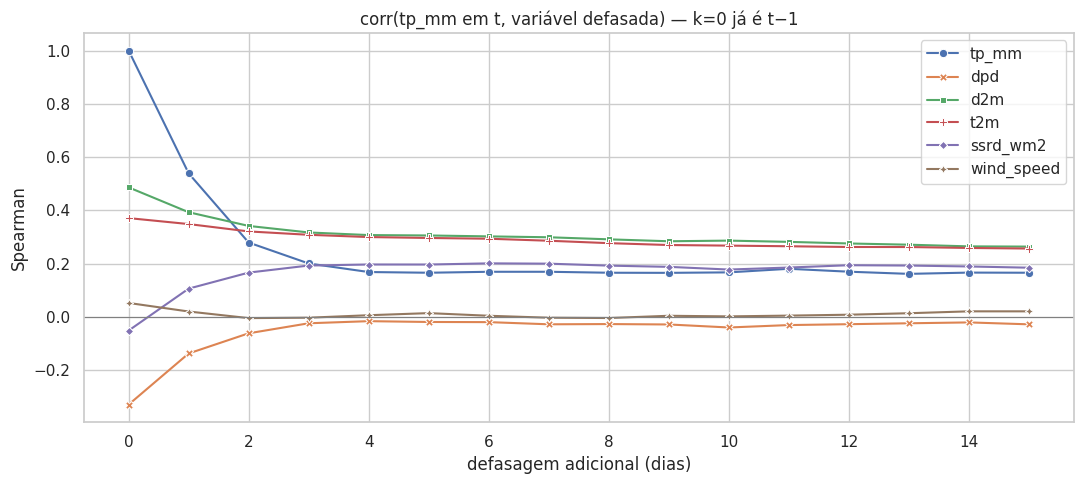

    tp_mm    dpd    d2m    t2m  ssrd_wm2  wind_speed
0   1.000 -0.329  0.486  0.371    -0.051       0.053
1   0.539 -0.137  0.393  0.349     0.106       0.021
2   0.279 -0.061  0.342  0.321     0.167      -0.004
3   0.201 -0.023  0.317  0.309     0.193      -0.003
4   0.169 -0.016  0.307  0.300     0.197       0.007
5   0.166 -0.019  0.306  0.297     0.197       0.015
6   0.170 -0.019  0.303  0.294     0.201       0.005
7   0.170 -0.027  0.299  0.286     0.200      -0.003
8   0.166 -0.026  0.291  0.277     0.193      -0.004
9   0.166 -0.028  0.284  0.270     0.188       0.005
10  0.168 -0.039  0.287  0.268     0.178       0.002
11  0.181 -0.030  0.282  0.265     0.186       0.005
12  0.170 -0.027  0.276  0.263     0.194       0.009
13  0.162 -0.024  0.271  0.263     0.193       0.014
14  0.167 -0.020  0.265  0.259     0.190       0.021
15  0.166 -0.027  0.264  0.257     0.185       0.021


In [56]:
def perfil_lag(col, kmax=15):
    return pd.Series({k: df.tp_mm.corr(df[col].shift(k), method="spearman")
                      for k in range(kmax + 1)}, name=col)

perfis = pd.concat([perfil_lag(c) for c in
                    ["tp_mm", "dpd", "d2m", "t2m", "ssrd_wm2", "wind_speed"]], axis=1)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=perfis, markers=True, dashes=False, ax=ax)
ax.axhline(0, color="gray", lw=.8)
ax.set(title="corr(tp_mm em t, variável defasada) — k=0 já é t−1",
       xlabel="defasagem adicional (dias)", ylabel="Spearman")
plt.tight_layout(); plt.show()
print(perfis.round(3))

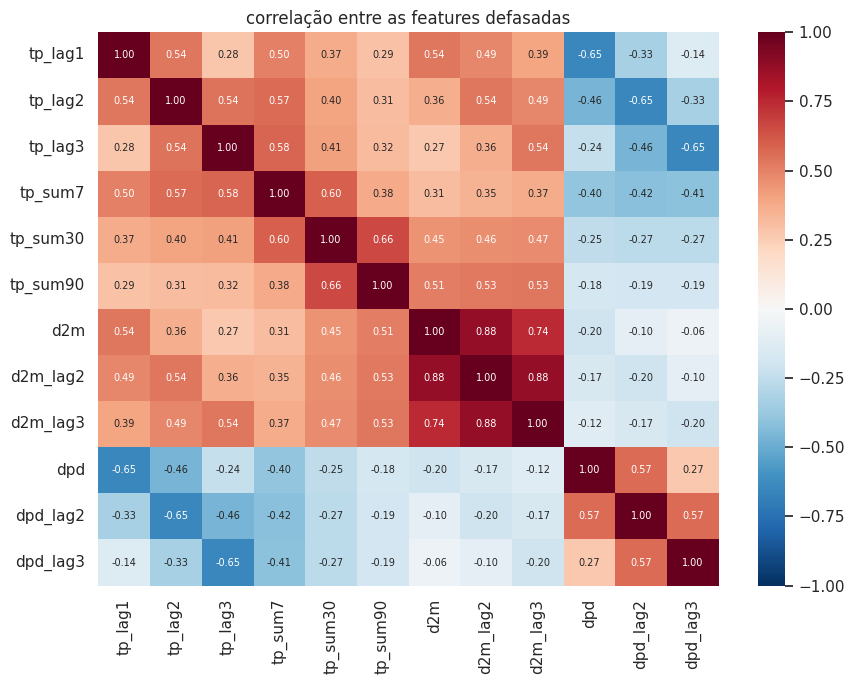

In [57]:
# redundância entre os próprios lags
LAGS = ["tp_lag1", "tp_lag2", "tp_lag3", "tp_sum7", "tp_sum30", "tp_sum90",
        "d2m", "d2m_lag2", "d2m_lag3", "dpd", "dpd_lag2", "dpd_lag3"]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[LAGS].corr(method="spearman"), annot=True, fmt=".2f",
            cmap="RdBu_r", vmin=-1, vmax=1, ax=ax, annot_kws={"size": 7})
ax.set(title="correlação entre as features defasadas")
plt.tight_layout(); plt.show()

Redundância entre d2m, d2m_lag2, d2m_lag3.

## Machine Learning

#### Divisão temporal

In [58]:
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

df = df.sort_values("date").reset_index(drop=True)
assert df.date.is_monotonic_increasing and not df.date.duplicated().any()

dev   = df[df.ano <= 2014].reset_index(drop=True)   # seleção de modelo mora aqui
teste = df[df.ano >= 2015].reset_index(drop=True)   # tocado uma única vez, no fim
y_te  = teste.tp_mm

# Guarda: toda coluna do df tem de estar em FEATURES ou em AUX. Se você
# criar uma coluna nova e esquecer de classificá-la, isso avisa aqui.
sobrando = set(df.columns) - set(FEATURES) - AUX
assert not sobrando, f"coluna fora de FEATURES e de AUX: {sobrando}"

print(f"{len(FEATURES)} features")
print(f"dev  : {dev.ano.min()}–{dev.ano.max()} ({len(dev)} dias)")
print(f"teste: {teste.ano.min()}–{teste.ano.max()} ({len(teste)} dias)")

na = df[FEATURES].isna().sum()
print("\nfeatures com NaN:", na[na > 0].to_dict() or "nenhuma")

22 features
dev  : 1980–2014 (12693 dias)
teste: 2015–2025 (4017 dias)

features com NaN: nenhuma


#### Configurações

In [59]:
from itertools import product

CONJUNTOS = {
    # tudo: atmosfera de véspera + histórico de chuva + calendário
    "completo": FEATURES,                                            # 22

    # atmosfera de t−1 + chuva de t−1 + calendário (nada anterior a ontem)
    "so_vespera": ["ssrd_wm2","t2m","t2m_min","t2m_max","d2m","dpd",
                   "wind_speed","wind_const","wind_dir_sin","wind_dir_cos",
                   "tp_lag1","day_sin","day_cos"],                    # 13

    # só o estado atmosférico de t−1, sem nenhuma informação de chuva
    "so_atmosfera": ["ssrd_wm2","t2m","t2m_min","t2m_max","d2m","dpd",
                     "wind_speed","wind_const","wind_dir_sin","wind_dir_cos",
                     "day_sin","day_cos"],                            # 12

    # só o histórico da própria chuva + umidade defasada, sem atmosfera de ontem
    "so_historico": ["tp_lag1","tp_lag2","tp_lag3",
                     "d2m_lag2","d2m_lag3","dpd_lag2","dpd_lag3",
                     "tp_sum7","tp_sum30","tp_sum90",
                     "day_sin","day_cos"],                            # 12
}

for k, v in CONJUNTOS.items():
    print(f"{k:14s} {len(v):2d} features")

# hiperparâmetros
HIPER = (
    [{"criterion": c, "max_depth": d, "min_samples_leaf": l}
     for c, d, l in product(["squared_error", "poisson"], [3, 5, 8], [50, 200, 500])]
    + [{"min_impurity_decrease": m, "min_samples_leaf": 50} for m in [0.5, 1.0, 2.0, 5.0]]
    + [{"ccp_alpha": a, "min_samples_leaf": 20} for a in [0.05, 0.1, 0.2, 0.5]]
)
print(f"\n{len(CONJUNTOS)} conjuntos × {len(HIPER)} hiperparâmetros = "
      f"{len(CONJUNTOS)*len(HIPER)} modelos")

completo       22 features
so_vespera     13 features
so_atmosfera   12 features
so_historico   12 features

4 conjuntos × 26 hiperparâmetros = 104 modelos


#### Ajuste de Hiperparâmetros

In [60]:
def rotulo(p):
    curto = {"min_samples_leaf": "leaf", "min_impurity_decrease": "mid",
             "max_depth": "d", "criterion": "crit", "ccp_alpha": "ccp"}
    return " ".join(f"{curto.get(k,k)}={v}" for k, v in p.items())

tscv = TimeSeriesSplit(n_splits=5, test_size=365*4)
folds = list(tscv.split(dev))
print("dias de treino por fold:", [len(a) for a, _ in folds])
print("dias de val por fold   :", [len(b) for _, b in folds], "\n")

linhas, config = [], {}
for (nome_cj, cols), hp in product(CONJUNTOS.items(), HIPER):
    r, mae, r_in, nf = [], [], [], []
    for i_tr, i_va in folds:
        tr, va = dev.iloc[i_tr], dev.iloc[i_va]
        m = DecisionTreeRegressor(random_state=42, **hp).fit(tr[cols], tr.tp_mm)
        p_va = m.predict(va[cols])
        r.append(mean_squared_error(va.tp_mm, p_va) ** .5)
        mae.append(mean_absolute_error(va.tp_mm, p_va))
        r_in.append(mean_squared_error(tr.tp_mm, m.predict(tr[cols])) ** .5)
        nf.append(m.get_n_leaves())
    chave = f"{nome_cj} | {rotulo(hp)}"
    config[chave] = (cols, hp)
    linhas.append({"modelo": chave, "features": nome_cj, "n_feats": len(cols),
                   "RMSE_cv": np.mean(r), "RMSE_std": np.std(r), "MAE_cv": np.mean(mae),
                   "RMSE_treino": np.mean(r_in), "folhas": np.mean(nf)})

# baselines no MESMO CV
bl = {n: {"r": [], "mae": []} for n in
      ["climatologia", "persistência", "média (dev)", "mediana (dev)"]}
for i_tr, i_va in folds:
    tr, va = dev.iloc[i_tr], dev.iloc[i_va]
    cmap = tr.groupby("doy").tp_mm.mean()
    preds = {"climatologia":  va.doy.map(cmap).fillna(tr.tp_mm.mean()).values,
             "persistência":  va.tp_lag1.values,
             "média (dev)":   np.full(len(va), tr.tp_mm.mean()),
             "mediana (dev)": np.full(len(va), tr.tp_mm.median())}
    for n, p in preds.items():
        bl[n]["r"].append(mean_squared_error(va.tp_mm, p) ** .5)
        bl[n]["mae"].append(mean_absolute_error(va.tp_mm, p))

for n, v in bl.items():
    linhas.append({"modelo": n, "features": "baseline", "n_feats": 0,
                   "RMSE_cv": np.mean(v["r"]), "RMSE_std": np.std(v["r"]),
                   "MAE_cv": np.mean(v["mae"]), "RMSE_treino": np.nan, "folhas": np.nan})

res = pd.DataFrame(linhas).set_index("modelo").sort_values("RMSE_cv")
res["gap"] = res.RMSE_cv - res.RMSE_treino
print(res.head(15).round(3).to_string())

dias de treino por fold: [5393, 6853, 8313, 9773, 11233]
dias de val por fold   : [1460, 1460, 1460, 1460, 1460] 

                                                features  n_feats  RMSE_cv  RMSE_std  MAE_cv  RMSE_treino  folhas    gap
modelo                                                                                                                  
so_vespera | crit=poisson d=8 leaf=200        so_vespera       13    7.500     1.073   4.215        7.198    31.4  0.302
so_vespera | crit=squared_error d=8 leaf=200  so_vespera       13    7.501     1.092   4.213        7.197    31.2  0.305
so_vespera | crit=poisson d=5 leaf=200        so_vespera       13    7.502     1.072   4.227        7.217    23.6  0.285
completo | crit=squared_error d=8 leaf=200      completo       22    7.502     1.092   4.213        7.190    32.0  0.312
completo | crit=squared_error d=5 leaf=200      completo       22    7.508     1.090   4.222        7.217    22.0  0.291
completo | crit=poisson d=5 leaf=50   

In [61]:
periodos = pd.DataFrame([
    {"fold": k + 1,
     "treino_ini": dev.date.iloc[i_tr[0]].date(),
     "treino_fim": dev.date.iloc[i_tr[-1]].date(),
     "n_treino":   len(i_tr),
     "val_ini":    dev.date.iloc[i_va[0]].date(),
     "val_fim":    dev.date.iloc[i_va[-1]].date(),
     "n_val":      len(i_va)}
    for k, (i_tr, i_va) in enumerate(folds)])

print(periodos.to_string(index=False))
print(f"\ndev  : {dev.date.min().date()} → {dev.date.max().date()} ({len(dev)} dias)")
print(f"teste: {teste.date.min().date()} → {teste.date.max().date()} ({len(teste)} dias)")

 fold treino_ini treino_fim  n_treino    val_ini    val_fim  n_val
    1 1980-04-01 1995-01-05      5393 1995-01-06 1999-01-04   1460
    2 1980-04-01 1999-01-04      6853 1999-01-05 2003-01-03   1460
    3 1980-04-01 2003-01-03      8313 2003-01-04 2007-01-02   1460
    4 1980-04-01 2007-01-02      9773 2007-01-03 2011-01-01   1460
    5 1980-04-01 2011-01-01     11233 2011-01-02 2014-12-31   1460

dev  : 1980-04-01 → 2014-12-31 (12693 dias)
teste: 2015-01-01 → 2025-12-30 (4017 dias)


In [62]:
for _, r in periodos.iterrows():
    print(f"Fold {r.fold}: treino {r.treino_ini.year}–{r.treino_fim.year} "
          f"({r.n_treino//365} anos) → validação {r.val_ini.year}–{r.val_fim.year}")

Fold 1: treino 1980–1995 (14 anos) → validação 1995–1999
Fold 2: treino 1980–1999 (18 anos) → validação 1999–2003
Fold 3: treino 1980–2003 (22 anos) → validação 2003–2007
Fold 4: treino 1980–2007 (26 anos) → validação 2007–2011
Fold 5: treino 1980–2011 (30 anos) → validação 2011–2014


Melhor por conjunto de features
                                                    features  n_feats  RMSE_cv  RMSE_std  MAE_cv  folhas
modelo                                                                                                  
completo | crit=squared_error d=8 leaf=200          completo       22    7.502     1.092   4.213    32.0
so_atmosfera | crit=squared_error d=8 leaf=200  so_atmosfera       12    7.593     1.067   4.332    31.4
so_historico | crit=squared_error d=3 leaf=200  so_historico       12    7.652     1.024   4.451     8.0
so_vespera | crit=poisson d=8 leaf=200            so_vespera       13    7.500     1.073   4.215    31.4
salvo: hiperparametros.png


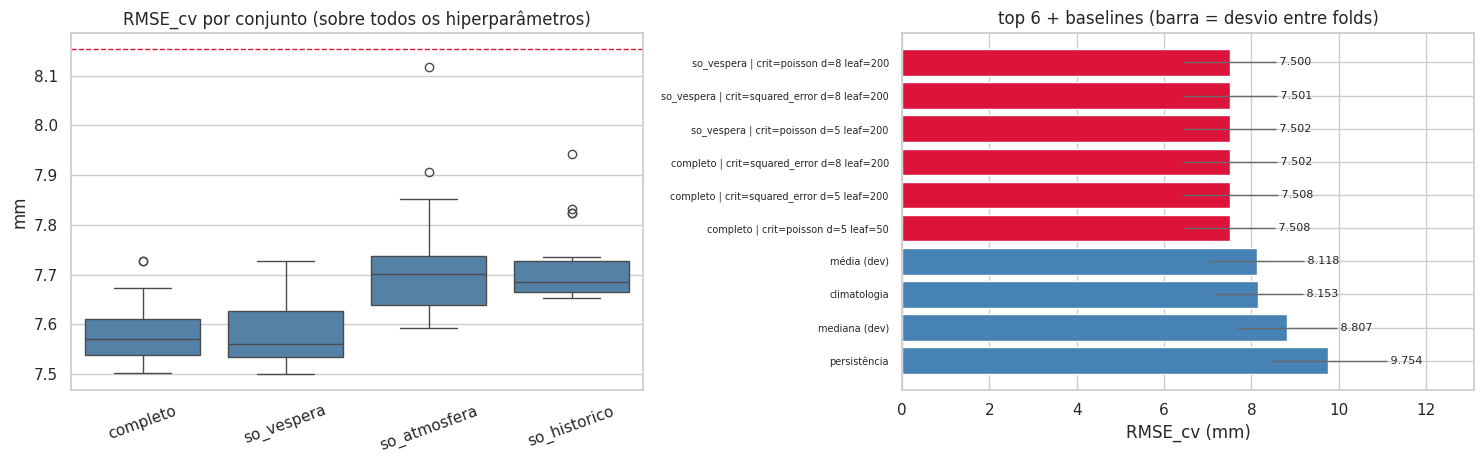

In [63]:
mod = res[res.features != "baseline"]

print("Melhor por conjunto de features")
print(mod.loc[mod.groupby("features").RMSE_cv.idxmin(),
              ["features", "n_feats", "RMSE_cv", "RMSE_std", "MAE_cv", "folhas"]]
         .round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

sns.boxplot(data=mod.reset_index(), x="features", y="RMSE_cv", ax=axes[0], color="steelblue",
            order=["completo", "so_vespera", "so_atmosfera", "so_historico"])
axes[0].axhline(res.loc["climatologia", "RMSE_cv"], color="crimson", ls="--", lw=1)
axes[0].set(title="RMSE_cv por conjunto (sobre todos os hiperparâmetros)", xlabel="", ylabel="mm")
axes[0].tick_params(axis="x", rotation=20)

# top 6 + baselines, com a dispersão entre folds como barra de erro
top = (pd.concat([mod.nsmallest(6, "RMSE_cv"), res[res.features == "baseline"]])
         .sort_values("RMSE_cv", ascending=False))
cores = ["crimson" if f != "baseline" else "steelblue" for f in top.features]
axes[1].barh(range(len(top)), top.RMSE_cv, xerr=top.RMSE_std,
             color=cores, error_kw={"lw": 1, "ecolor": "dimgray"})
axes[1].set_yticks(range(len(top)))
axes[1].set_yticklabels(top.index, fontsize=7)
axes[1].set(title="top 6 + baselines (barra = desvio entre folds)", xlabel="RMSE_cv (mm)", ylabel="")
axes[1].set_xlim(0, (top.RMSE_cv + top.RMSE_std).max() * 1.18)
for i, (v, e) in enumerate(zip(top.RMSE_cv, top.RMSE_std)):
    axes[1].text(v + e, i, f" {v:.3f}", va="center", fontsize=8)

plt.tight_layout();
salvar("hiperparametros")
plt.show()

salvo: hiperparametros_rmse.png


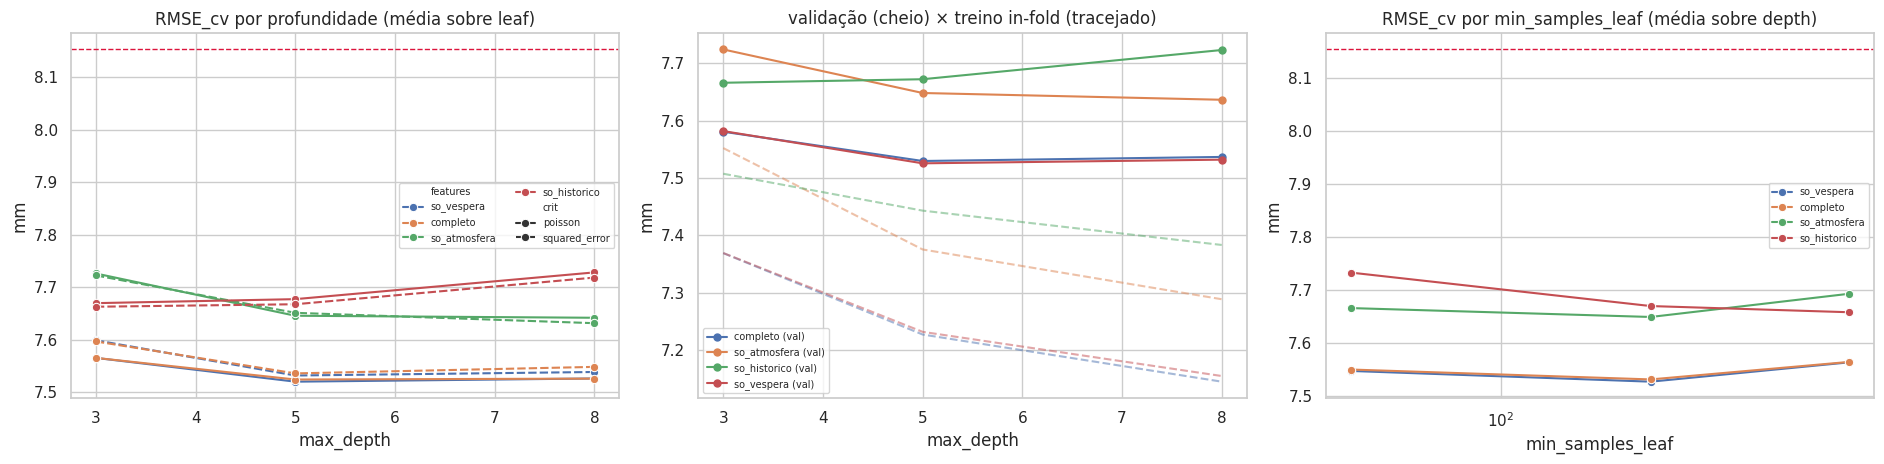

In [64]:
arv = res[res.features != "baseline"].copy()
arv["depth"] = arv.index.str.extract(r"\bd=(\d+)")[0].astype(float).values
arv["leaf"]  = arv.index.str.extract(r"leaf=(\d+)")[0].astype(float).values
arv["crit"]  = arv.index.str.extract(r"crit=(\w+)")[0].values

rmse_clim = res.loc["climatologia", "RMSE_cv"]
prof = arv[arv.depth.notna()]

fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))

# 1. profundidade × RMSE_cv
sns.lineplot(data=prof, x="depth", y="RMSE_cv", hue="features", style="crit",
             marker="o", errorbar=None, ax=axes[0])
axes[0].axhline(rmse_clim, color="crimson", ls="--", lw=1)
axes[0].set(title="RMSE_cv por profundidade (média sobre leaf)", xlabel="max_depth", ylabel="mm")
axes[0].legend(fontsize=7, ncol=2)

# 2. validação × treino in-fold — abertura indica overfitting
for cj, g in prof.groupby("features"):
    med = g.groupby("depth")[["RMSE_cv", "RMSE_treino"]].mean()
    l, = axes[1].plot(med.index, med.RMSE_cv, "-o", ms=5, label=f"{cj} (val)")
    axes[1].plot(med.index, med.RMSE_treino, "--", alpha=.5, color=l.get_color())
axes[1].set(title="validação (cheio) × treino in-fold (tracejado)", xlabel="max_depth", ylabel="mm")
axes[1].legend(fontsize=7)

# 3. min_samples_leaf × RMSE_cv — o outro eixo de regularização
sns.lineplot(data=prof, x="leaf", y="RMSE_cv", hue="features",
             marker="o", errorbar=None, ax=axes[2])
axes[2].axhline(rmse_clim, color="crimson", ls="--", lw=1)
axes[2].set(title="RMSE_cv por min_samples_leaf (média sobre depth)",
            xlabel="min_samples_leaf", ylabel="mm", xscale="log")
axes[2].legend(fontsize=7)

plt.tight_layout();
salvar("hiperparametros_rmse")
plt.show()

selecionado na CV: so_vespera | crit=poisson d=8 leaf=200
{'RMSE_cv': 7.500404943513395, 'RMSE_std': 1.072932831249162, 'MAE_cv': 4.2153829464134045, 'folhas': 31.4} 



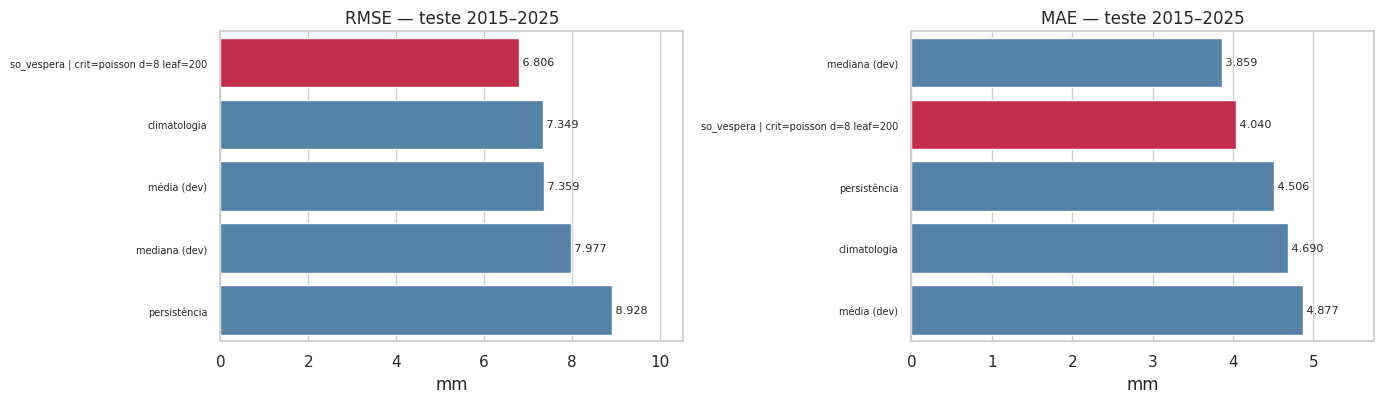

                                         RMSE    MAE  vs_clim_%
modelo                                                         
so_vespera | crit=poisson d=8 leaf=200  6.806  4.040      7.391
climatologia                            7.349  4.690      0.000
média (dev)                             7.359  4.877     -0.134
mediana (dev)                           7.977  3.859     -8.542
persistência                            8.928  4.506    -21.477


In [65]:
melhor = res[res.features != "baseline"].index[0]
cols, hp = config[melhor]
print("selecionado na CV:", melhor)
print(res.loc[melhor, ["RMSE_cv", "RMSE_std", "MAE_cv", "folhas"]].round(3).to_dict(), "\n")

final = DecisionTreeRegressor(random_state=42, **hp).fit(dev[cols], dev.tp_mm)

clim_map = dev.groupby("doy").tp_mm.mean()
finais = {melhor:          final.predict(teste[cols]),
          "climatologia":  teste.doy.map(clim_map).fillna(dev.tp_mm.mean()).values,
          "persistência":  teste.tp_lag1.values,
          "média (dev)":   np.full(len(teste), dev.tp_mm.mean()),
          "mediana (dev)": np.full(len(teste), dev.tp_mm.median())}

fin = (pd.DataFrame([{"modelo": n,
                      "RMSE": mean_squared_error(y_te, p) ** .5,
                      "MAE":  mean_absolute_error(y_te, p)} for n, p in finais.items()])
         .set_index("modelo"))
fin["vs_clim_%"] = 100 * (1 - fin.RMSE / fin.loc["climatologia", "RMSE"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for a, m in zip(axes, ["RMSE", "MAE"]):
    d = fin.sort_values(m)
    cores = ["crimson" if i == melhor else "steelblue" for i in d.index]
    sns.barplot(x=d[m], y=d.index, palette=cores, hue=d.index, legend=False, ax=a)
    a.set(title=f"{m} — teste {teste.ano.min()}–{teste.ano.max()}", xlabel="mm", ylabel="")
    a.set_xlim(0, d[m].max() * 1.18)
    a.tick_params(axis="y", labelsize=7)
    for i, v in enumerate(d[m]):
        a.text(v, i, f" {v:.3f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

print(fin.sort_values("RMSE").round(3).to_string())

Árvore de decisão com critério **Poisson**, `max_depth=8`, `min_samples_leaf=200`,
sobre as **13 features de véspera** (`so_vespera`). Selecionada por validação
cruzada temporal (5 folds de 4 anos, 1981–2014); o teste foi usado uma vez só.

**RMSE de 6,806 mm** no teste (2015–2025), 7,4% abaixo da climatologia (7,349 mm).

Duas observações:

**A escolha entre conjuntos é apertada.** Na CV: 7,500 (`so_vespera`), 7,502
(`completo`), 7,593 (`so_atmosfera`), 7,652 (`so_historico`) mm. O empate entre os
dois primeiros indica que as 9 features defasadas além de t−1 não agregam depois de `tp_lag1` e da atmosfera de ontem.

**O ganho está no volume, não nos dias secos.** A mediana tem o melhor MAE da
tabela (3,859 mm) e mesmo assim perde 8,5% em RMSE para a climatologia — prever
perto de zero acerta os muitos dias sem chuva e erra os poucos eventos.

#### Treino - Árvore de Decisão


46 folhas | RMSE teste: 6.806  (final: 6.806)
salvo: arvore_final.png


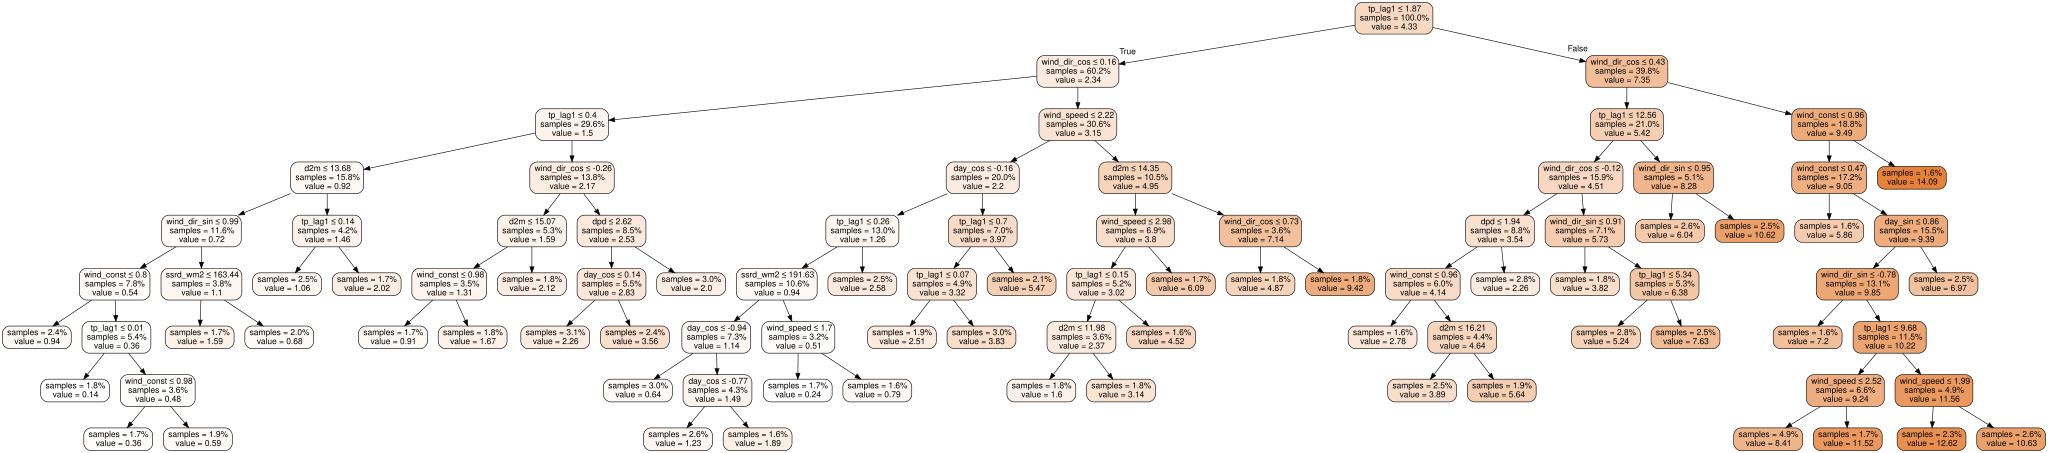

In [66]:
def salvar_arvore(src, nome):
    """Salva um graphviz.Source como PNG em FIGDIR."""
    src.render(filename=str(FIGDIR / nome), format="png", cleanup=True)
    print(f"salvo: {nome}.png")
    return src

exp = DecisionTreeRegressor(criterion="poisson", max_depth=8,
                            min_samples_leaf=200, random_state=42).fit(dev[cols], dev.tp_mm)

print(f"{exp.get_n_leaves()} folhas | RMSE teste: "
      f"{mean_squared_error(y_te, exp.predict(teste[cols])) ** .5:.3f}  "
      f"(final: {mean_squared_error(y_te, final.predict(teste[cols])) ** .5:.3f})")

g_final = graphviz.Source(export_graphviz(final, out_file=None, feature_names=cols,
                                          filled=True, rounded=True, impurity=False,
                                          proportion=True, precision=2,
                                          special_characters=True))

salvar_arvore(g_final, "arvore_final")

g_final

#### Importância das Features

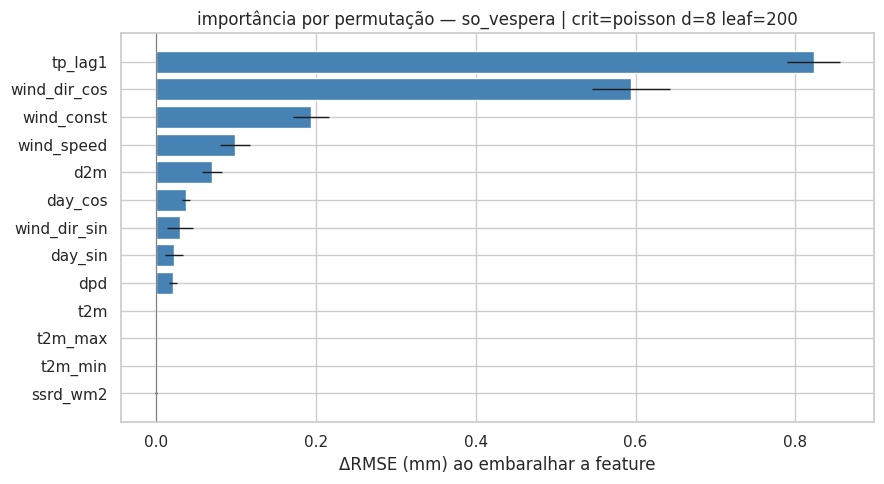

               media     std
tp_lag1       0.8227  0.0329
wind_dir_cos  0.5945  0.0488
wind_const    0.1937  0.0229
wind_speed    0.0984  0.0184
d2m           0.0697  0.0130
day_cos       0.0370  0.0052
wind_dir_sin  0.0296  0.0161
day_sin       0.0222  0.0107
dpd           0.0208  0.0049
t2m           0.0000  0.0000
t2m_max       0.0000  0.0000
t2m_min       0.0000  0.0000
ssrd_wm2     -0.0001  0.0015

features que nunca entram em split: ['t2m', 't2m_min', 't2m_max']
features com importância desprezível (média < 2×std): ['wind_dir_sin', 'ssrd_wm2']


In [67]:
from sklearn.inspection import permutation_importance

pi = permutation_importance(final, teste[cols], y_te, n_repeats=20,
                            random_state=42, scoring="neg_root_mean_squared_error")

imp = pd.DataFrame({"media": pi.importances_mean, "std": pi.importances_std},
                   index=cols).sort_values("media", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp.index[::-1], imp.media[::-1], xerr=imp["std"][::-1],
        color="steelblue", error_kw={"lw": 1})
ax.axvline(0, color="gray", lw=.8)
ax.set(title=f"importância por permutação — {melhor}",
       xlabel="ΔRMSE (mm) ao embaralhar a feature")
plt.tight_layout(); plt.show()

print(imp.round(4))
print("\nfeatures que nunca entram em split:",
      [c for c, v in zip(cols, final.feature_importances_) if v == 0])
print("features com importância desprezível (média < 2×std):",
      list(imp[imp.media < 2 * imp["std"]].index))

In [68]:
teste_f = teste.copy()
teste_f["folha"] = final.apply(teste[cols])
teste_f["pred"]  = final.predict(teste[cols])

perfil = teste_f.groupby("folha").agg(
    n=("tp_mm", "size"),
    pred=("pred", "first"),
    obs=("tp_mm", "mean"),
    p90_obs=("tp_mm", lambda x: x.quantile(.9)),
    tp_lag1=("tp_lag1", "mean"),
    d2m=("d2m", "mean"),
    dpd=("dpd", "mean"),
    vento=("wind_speed", "mean"),
    dir_cos=("wind_dir_cos", "mean"),
    mes_moda=("mes", lambda x: x.mode()[0]),
).sort_values("pred", ascending=False)

perfil["vies"] = perfil.pred - perfil.obs
perfil["n_dev"] = pd.Series(np.bincount(final.apply(dev[cols]),
                                        minlength=final.tree_.node_count))
perfil["pct_dev"] = 100 * perfil.n_dev / len(dev)
perfil["pct_teste"] = 100 * perfil.n / len(teste)

print(perfil.round(2).to_string())
print(f"\nfolhas vazias no teste: {final.get_n_leaves() - len(perfil)}")

         n   pred    obs  p90_obs    tp_lag1        d2m   dpd  vento  dir_cos  mes_moda  vies  n_dev  pct_dev  pct_teste
folha                                                                                                                   
90      66  14.09  12.46    26.52  10.360000  17.770000  2.20   3.11     0.73         1  1.62    208     1.64       1.64
87      64  12.62   8.38    20.85  16.850000  17.629999  1.58   1.63     0.81        12  4.24    287     2.26       1.59
85      70  11.52   8.72    21.66   4.930000  16.230000  3.03   3.13     0.84        12  2.80    222     1.75       1.74
88     101  10.63  10.47    25.67  19.030001  16.809999  1.95   2.80     0.85        10  0.16    329     2.59       2.51
75     121  10.62   7.21    16.53  22.240000  15.060000  0.87   2.32    -0.06        10  3.41    314     2.47       3.01
57      85   9.42   6.41    17.58   0.420000  16.389999  4.48   2.77     0.92         9  3.02    230     1.81       2.12
84     161   8.41   8.09    18.0

In [69]:
final.feature_importances_

array([0.00633389, 0.        , 0.        , 0.        , 0.03157827,
       0.00938858, 0.07402627, 0.02980223, 0.02613158, 0.17340231,
       0.58291724, 0.0071206 , 0.05929904])

In [70]:
from sklearn.tree import export_text
print(export_text(final, feature_names=list(cols), max_depth=2, decimals=1))

# e os números da raiz:
t = final.tree_
print("raiz:", cols[t.feature[0]], "<=", round(t.threshold[0], 2))
print("filhos:", t.value[t.children_left[0]][0][0].round(2),
                 t.value[t.children_right[0]][0][0].round(2))

|--- tp_lag1 <= 1.9
|   |--- wind_dir_cos <= 0.2
|   |   |--- tp_lag1 <= 0.4
|   |   |   |--- truncated branch of depth 6
|   |   |--- tp_lag1 >  0.4
|   |   |   |--- truncated branch of depth 4
|   |--- wind_dir_cos >  0.2
|   |   |--- wind_speed <= 2.2
|   |   |   |--- truncated branch of depth 6
|   |   |--- wind_speed >  2.2
|   |   |   |--- truncated branch of depth 5
|--- tp_lag1 >  1.9
|   |--- wind_dir_cos <= 0.4
|   |   |--- tp_lag1 <= 12.6
|   |   |   |--- truncated branch of depth 5
|   |   |--- tp_lag1 >  12.6
|   |   |   |--- truncated branch of depth 2
|   |--- wind_dir_cos >  0.4
|   |   |--- wind_const <= 1.0
|   |   |   |--- truncated branch of depth 6
|   |   |--- wind_const >  1.0
|   |   |   |--- value: [14.1]

raiz: tp_lag1 <= 1.87
filhos: 2.34 7.35


In [75]:
from scipy.stats import percentileofscore
print(df.tp_mm.quantile([.5, .9, .95, .99]).round(1))
print("percentil de 14,09:", round(percentileofscore(df.tp_mm, 14.09), 1))
acima = df.tp_mm > 14.09
print(f"dias acima do teto: {acima.sum()} ({100*acima.mean():.1f}%)")
print(f"chuva acumulada nesses dias: {100*df.tp_mm[acima].sum()/df.tp_mm.sum():.0f}% do total")

0.50     0.9
0.90    12.9
0.95    18.8
0.99    36.0
Name: tp_mm, dtype: float64
percentil de 14,09: 91.4
dias acima do teto: 1440 (8.6%)
chuva acumulada nesses dias: 49% do total


In [76]:
acima_te = teste.tp_mm > 14.09
print(f"{acima_te.sum()} dias ({100*acima_te.mean():.1f}%), "
      f"{100*teste.tp_mm[acima_te].sum()/teste.tp_mm.sum():.0f}% da chuva do teste")

332 dias (8.3%), 48% da chuva do teste


salvo: arvore_topo.png
raiz: tp_lag1 <= 1.87
  não  -> 2.34 mm (60% dos dias)
  sim  -> 7.35 mm (40% dos dias)

46 folhas, previsões de 0.14 a 14.09 mm
máximo observado na série: 192.7 mm


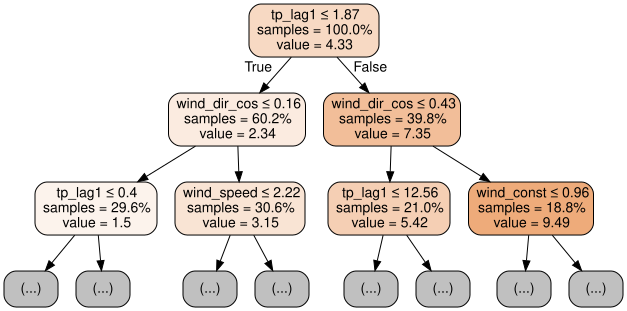

In [71]:
# --- topo da árvore final (mesma árvore do 6,806 mm, só desenhada até o nível 2)
g_topo = graphviz.Source(export_graphviz(
    final, out_file=None, feature_names=cols, max_depth=2,
    filled=True, rounded=True, impurity=False,
    proportion=True, precision=2, special_characters=True))

salvar_arvore(g_topo, "arvore_topo")

# --- a raiz em texto, para a legenda do slide
t = final.tree_
raiz_var = cols[t.feature[0]]
raiz_lim = t.threshold[0]
esq = t.value[t.children_left[0]][0][0]
dir_ = t.value[t.children_right[0]][0][0]
print(f"raiz: {raiz_var} <= {raiz_lim:.2f}")
print(f"  não  -> {esq:.2f} mm ({100*t.weighted_n_node_samples[t.children_left[0]]/t.weighted_n_node_samples[0]:.0f}% dos dias)")
print(f"  sim  -> {dir_:.2f} mm ({100*t.weighted_n_node_samples[t.children_right[0]]/t.weighted_n_node_samples[0]:.0f}% dos dias)")

# --- amplitude das folhas, o número solto do slide
folhas = t.value[t.children_left == -1].ravel()
print(f"\n{final.get_n_leaves()} folhas, previsões de {folhas.min():.2f} a {folhas.max():.2f} mm")
print(f"máximo observado na série: {df.tp_mm.max():.1f} mm")

g_topo

**Interpretação da árvore**

A árvore final tem 46 folhas, cada uma prevendo um valor constante entre 0,14 e
14,09 mm. O perfil meteorológico médio dos dias de cada folha (`perfil`, via
`final.apply()`) mostra o que cada regra captura.

A importância por permutação, medida no teste, ordena as features assim:
`tp_lag1` (0,823 ± 0,033), `wind_dir_cos` (0,595 ± 0,049), `wind_const` (0,194),
`wind_speed` (0,098), `d2m` (0,070). As três variáveis de temperatura — `t2m`,
`t2m_min` e `t2m_max` — não entram em nenhum split; `wind_dir_sin` e `ssrd_wm2`
entram, mas com importância indistinguível de zero.

A chuva da véspera é o principal organizador das folhas, com a direção e a
constância do vento em seguida. A sazonalidade aparece sem depender do calendário:
`day_sin` e `day_cos` têm importância marginal (0,022 e 0,037), e ainda assim,
entre as 15 folhas de maior previsão, 9 têm o verão como estação modal e nenhuma o
inverno — nas 15 mais secas, o inverso. O ciclo anual entra pela umidade e pela
chuva de véspera.

A calibração é boa no agregado, com viés médio de +0,19 mm, mas a previsão
constante não representa os extremos: nas 10 folhas mais chuvosas o percentil 90
observado é em média o dobro da previsão. O agrupamento abaixo usa terços da
distribuição de `tp_lag1` entre as folhas — rótulos descritivos para leitura do
gráfico, não regimes meteorológicos.

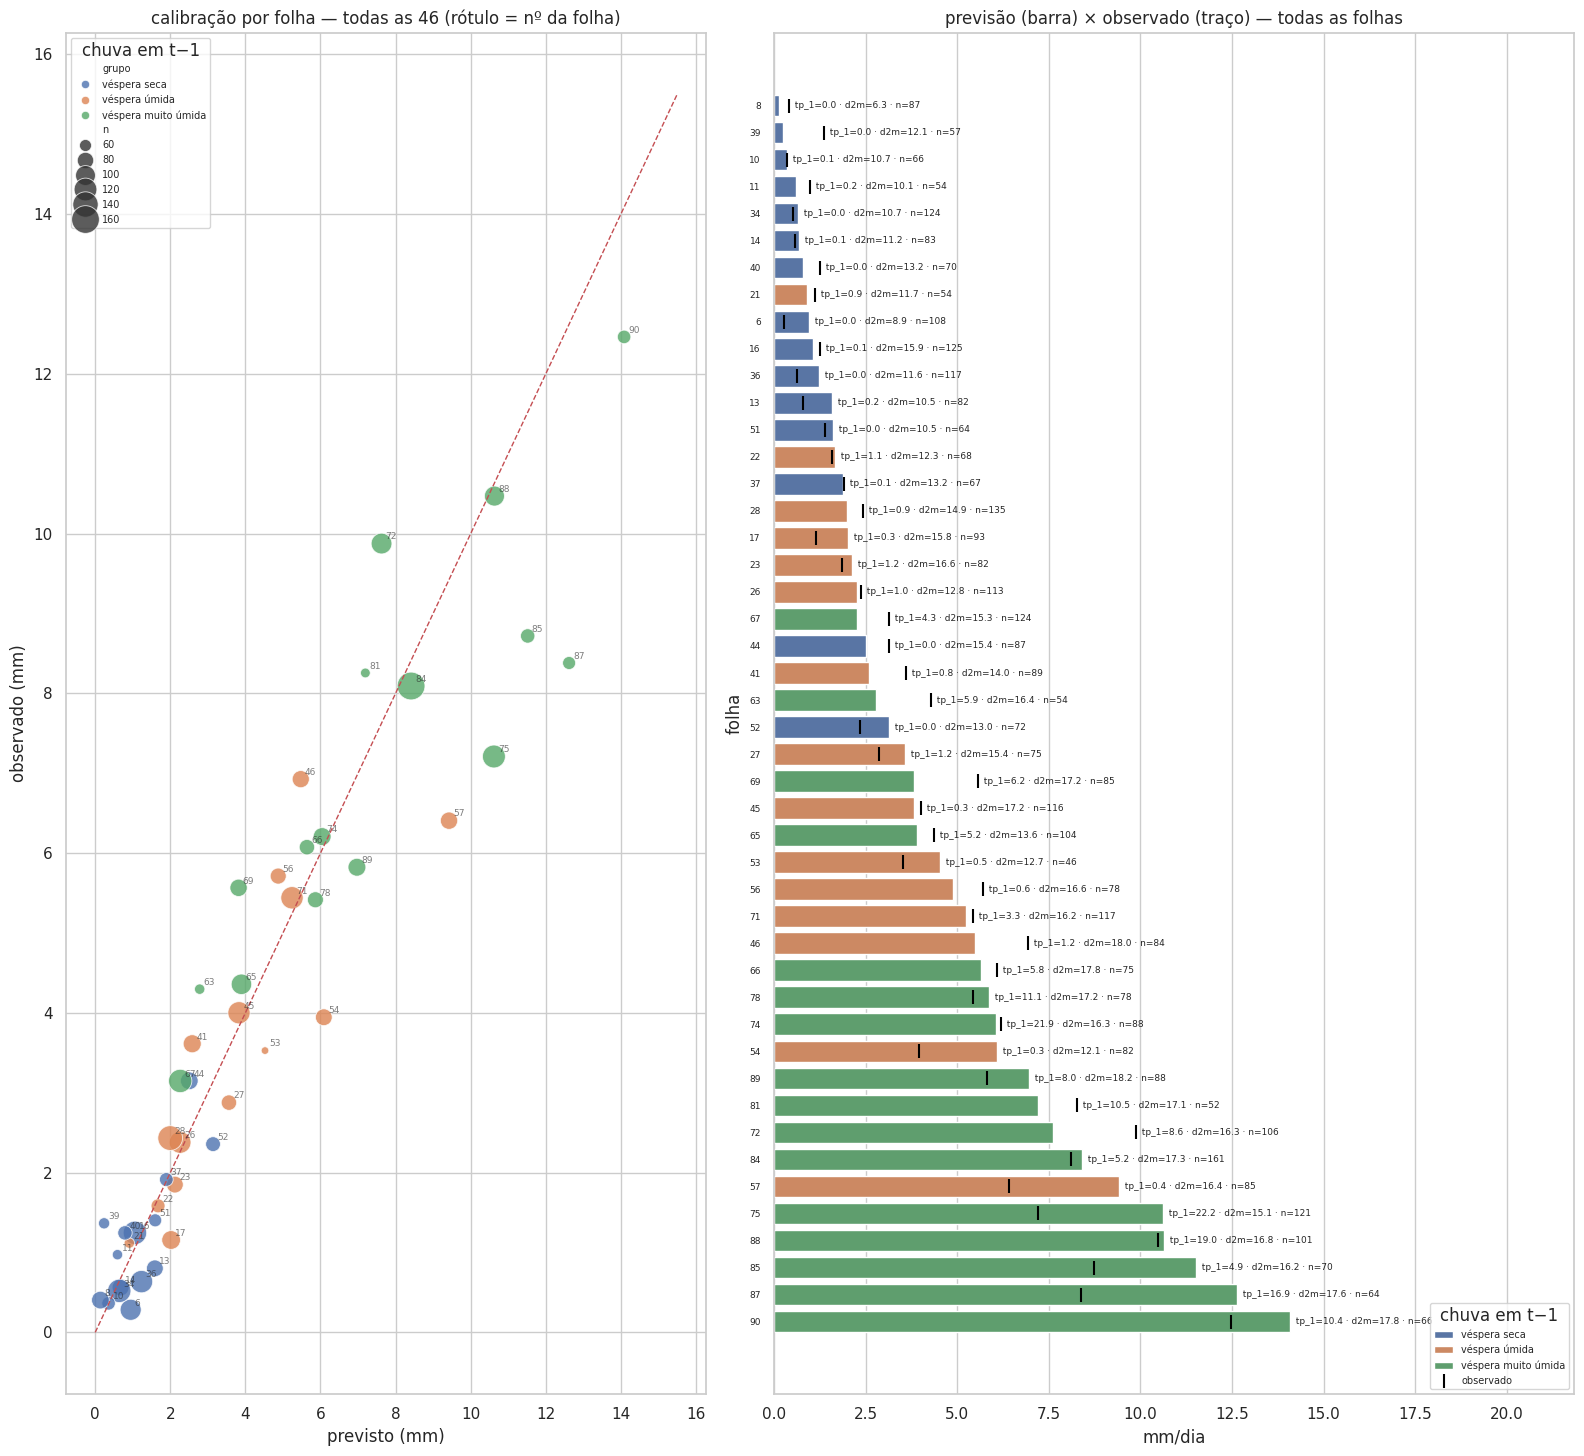

         n  pct_dev  pct_teste   pred    obs  vies  p90_obs    tp_lag1        d2m   dpd  vento  dir_cos  mes_moda
folha                                                                                                            
90      66     1.64       1.64  14.09  12.46  1.62    26.52  10.360000  17.770000  2.20   3.11     0.73         1
87      64     2.26       1.59  12.62   8.38  4.24    20.85  16.850000  17.629999  1.58   1.63     0.81        12
85      70     1.75       1.74  11.52   8.72  2.80    21.66   4.930000  16.230000  3.03   3.13     0.84        12
88     101     2.59       2.51  10.63  10.47  0.16    25.67  19.030001  16.809999  1.95   2.80     0.85        10
75     121     2.47       3.01  10.62   7.21  3.41    16.53  22.240000  15.060000  0.87   2.32    -0.06        10
57      85     1.81       2.12   9.42   6.41  3.02    17.58   0.420000  16.389999  4.48   2.77     0.92         9
84     161     4.85       4.01   8.41   8.09  0.32    18.03   5.210000  17.280001  2.47 

In [72]:
p = perfil.copy()

q33, q67 = p.tp_lag1.quantile([1/3, 2/3])
p["grupo"] = pd.cut(p.tp_lag1, [-np.inf, q33, q67, np.inf],
                    labels=["véspera seca", "véspera úmida", "véspera muito úmida"])

n_folhas = len(p)
alt = max(6.5, 0.32 * n_folhas)          # ~0,32 pol por folha

fig, axes = plt.subplots(1, 2, figsize=(16, alt),
                         gridspec_kw={"width_ratios": [1, 1.25]})

# calibração — todas as folhas, tamanho do ponto = n de dias
sns.scatterplot(data=p, x="pred", y="obs", hue="grupo", size="n",
                sizes=(30, 400), alpha=.8, ax=axes[0])
lim = [0, p[["pred", "obs"]].max().max() * 1.1]
axes[0].plot(lim, lim, "r--", lw=1)
for i, r in p.iterrows():
    axes[0].annotate(int(i), (r.pred, r.obs), fontsize=6.5, alpha=.6,
                     xytext=(3, 3), textcoords="offset points")
axes[0].set(title=f"calibração por folha — todas as {n_folhas} (rótulo = nº da folha)",
            xlabel="previsto (mm)", ylabel="observado (mm)")
axes[0].legend(title="chuva em t−1", fontsize=7, loc="upper left")

# previsão × observado — todas as folhas
p2 = p.sort_values("pred")
sns.barplot(x=p2.pred, y=[str(i) for i in p2.index], hue=p2.grupo,
            dodge=False, ax=axes[1])
axes[1].scatter(p2.obs, range(len(p2)), color="black", marker="|", s=90, zorder=5,
                label="observado")
for j, (i, r) in enumerate(p2.iterrows()):
    axes[1].text(max(r.pred, r.obs), j,
                 f"  tp_1={r.tp_lag1:.1f} · d2m={r.d2m:.1f} · n={int(r.n)}",
                 va="center", fontsize=6.5)
axes[1].set(title="previsão (barra) × observado (traço) — todas as folhas",
            xlabel="mm/dia", ylabel="folha")
axes[1].set_xlim(0, max(p2.pred.max(), p2.obs.max()) * 1.55)
axes[1].tick_params(axis="y", labelsize=6.5)
axes[1].legend(title="chuva em t−1", fontsize=7, loc="lower right")

plt.tight_layout(); plt.show()

# tabela completa, ordenada por previsão
cols_tab = ["n", "pct_dev", "pct_teste", "pred", "obs", "vies", "p90_obs",
            "tp_lag1", "d2m", "dpd", "vento", "dir_cos", "mes_moda"]
print(p.sort_values("pred", ascending=False)[cols_tab].round(2).to_string())

# ruído esperado em obs, por folha — o que separa viés real de amostra pequena
p["se_obs"] = teste_f.groupby("folha").tp_mm.std().reindex

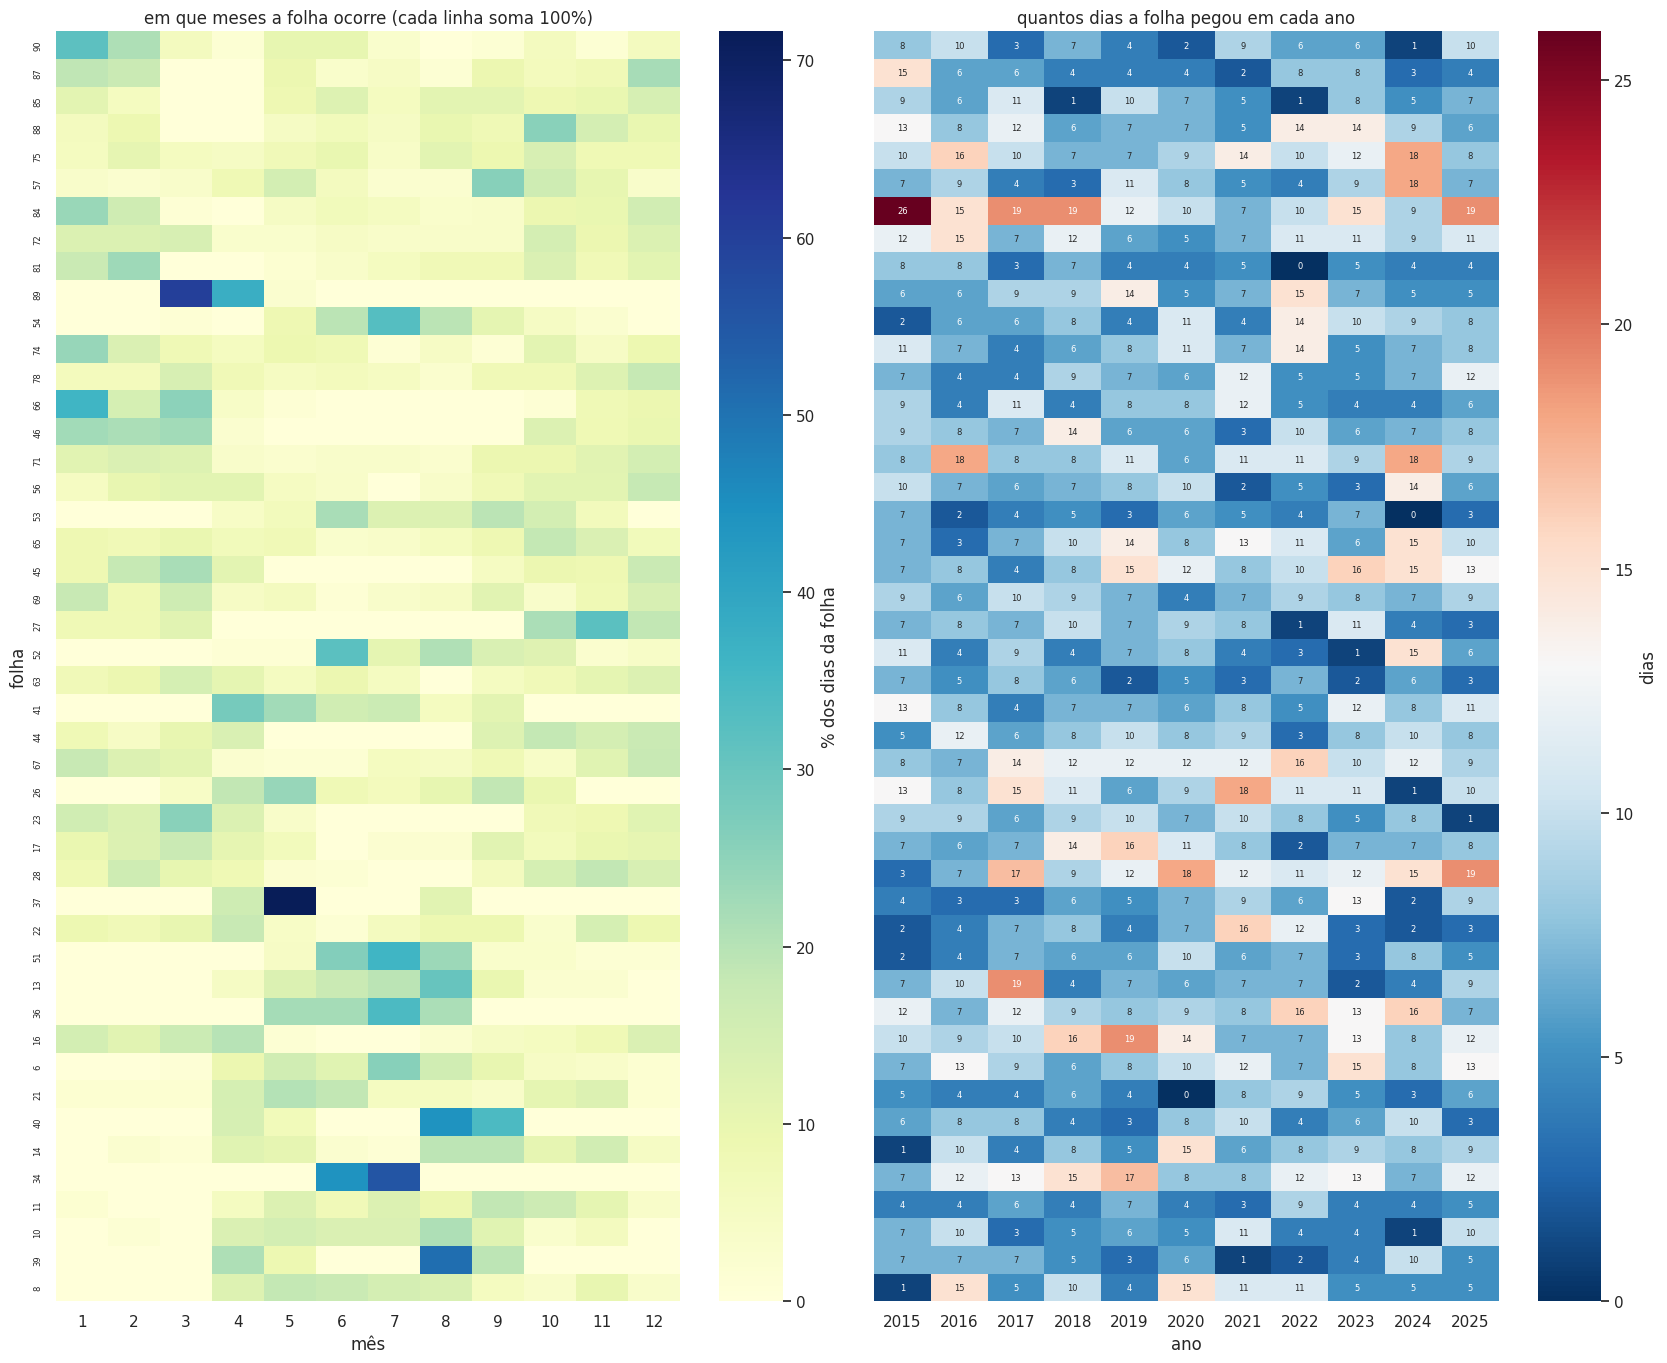

         n       pred  anos_sem  dias_ano_min  dias_ano_max  mes_pico  pct_no_pico
folha                                                                             
90      66  14.086562         0             1            10         1         32.0
87      64  12.622084         0             2            15        12         22.0
85      70  11.518799         0             1            11        12         14.0
88     101  10.633780         0             5            14        10         26.0
75     121  10.619203         0             7            18        10         14.0
57      85   9.423959         0             3            18         9         26.0
84     161   8.412797         0             7            26         1         24.0
72     106   7.626303         0             5            15        10         15.0
81      52   7.195460         1             0             8         2         23.0
89      88   6.971132         0             5            15         3         60.0
54  

In [73]:
ordem = perfil.sort_values("pred", ascending=False).index
alt = max(8, 0.30 * len(ordem))

mes_folha = pd.crosstab(teste_f.folha, teste_f.mes, normalize="index").reindex(ordem)
ano_cont  = pd.crosstab(teste_f.folha, teste_f.ano).reindex(ordem)

fig, axes = plt.subplots(1, 2, figsize=(17, alt), sharey=True)

sns.heatmap(mes_folha * 100, cmap="YlGnBu", ax=axes[0], vmin=0,
            cbar_kws={"label": "% dos dias da folha"})
axes[0].set(title="em que meses a folha ocorre (cada linha soma 100%)",
            xlabel="mês", ylabel="folha")

sns.heatmap(ano_cont, cmap="RdBu_r", ax=axes[1], vmin=0,
            annot=True, fmt="d", annot_kws={"size": 6},
            cbar_kws={"label": "dias"})
axes[1].set(title="quantos dias a folha pegou em cada ano", xlabel="ano", ylabel="")

for a in axes:
    a.tick_params(axis="y", labelsize=6)
plt.tight_layout(); plt.show()

resumo = pd.DataFrame({
    "n":            perfil.n.reindex(ordem),
    "pred":         perfil.pred.reindex(ordem),
    "anos_sem":     (ano_cont == 0).sum(1),          # anos em que a folha não apareceu
    "dias_ano_min": ano_cont.min(1),
    "dias_ano_max": ano_cont.max(1),
    "mes_pico":     mes_folha.idxmax(1),
    "pct_no_pico":  (mes_folha.max(1) * 100).round(0),
})
print(resumo.to_string())

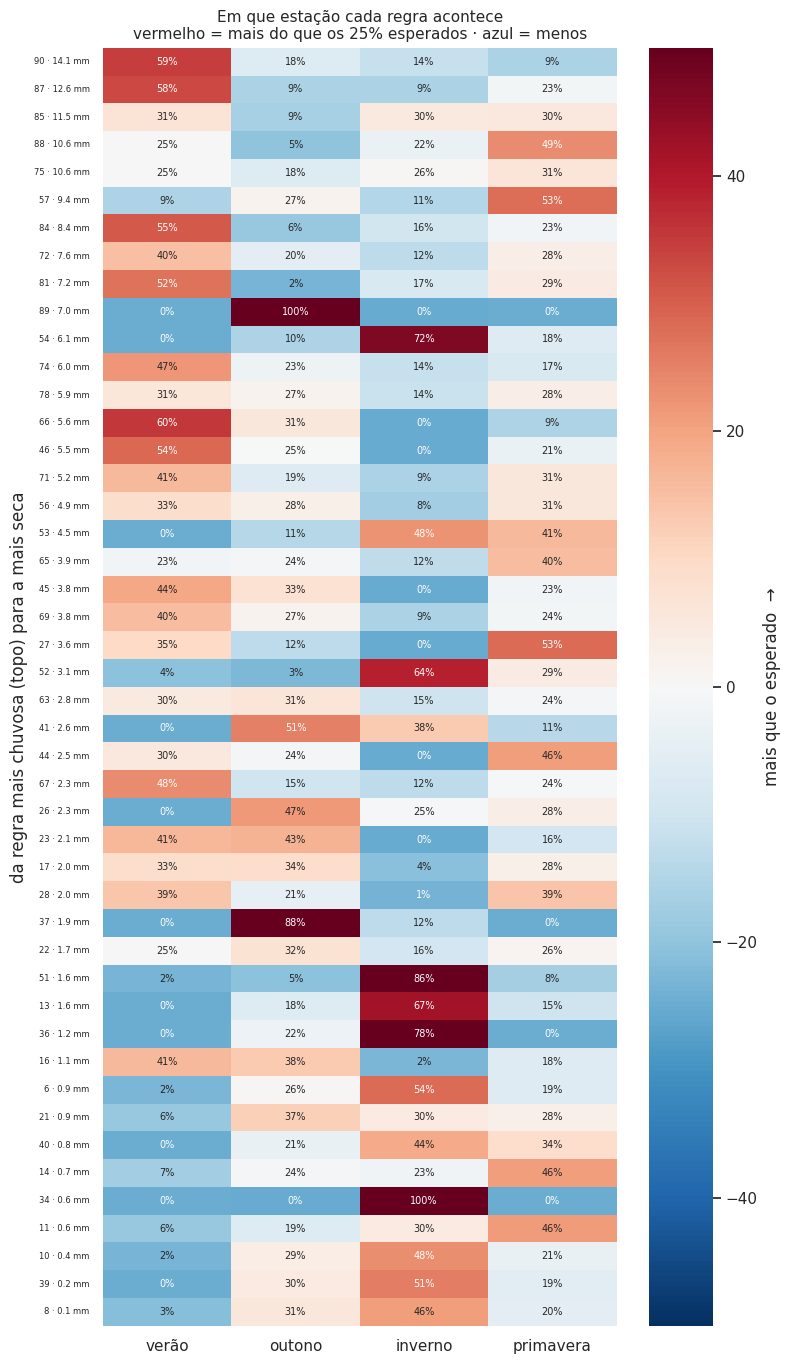

In [85]:
est = {12:"verão", 1:"verão", 2:"verão",
       3:"outono", 4:"outono", 5:"outono",
       6:"inverno", 7:"inverno", 8:"inverno",
       9:"primavera", 10:"primavera", 11:"primavera"}
teste_f["estacao"] = teste_f.mes.map(est)
EST = ["verão", "outono", "inverno", "primavera"]

ordem   = perfil.sort_values("pred", ascending=False).index
est_pct = (pd.crosstab(teste_f.folha, teste_f.estacao, normalize="index")
             .reindex(ordem)[EST] * 100)
peso    = teste_f.estacao.value_counts(normalize=True)[EST] * 100

cor = est_pct - peso        # a cor mostra o quanto foge dos 25%

rot     = [f"{i} · {perfil.pred[i]:.1f} mm" for i in ordem]
rotulos = est_pct.round(0).astype(int).astype(str) + "%"

fig, ax = plt.subplots(figsize=(8, max(8, 0.30 * len(ordem))))
sns.heatmap(cor, annot=rotulos, fmt="", annot_kws={"size": 7},
            cmap="RdBu_r", center=0, vmin=-50, vmax=50,
            yticklabels=rot, ax=ax,
            cbar_kws={"label": "mais que o esperado  →"})

ax.set_title("Em que estação cada regra acontece\n"
             "vermelho = mais do que os 25% esperados · azul = menos",
             fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("da regra mais chuvosa (topo) para a mais seca")
ax.tick_params(axis="y", labelsize=6)
plt.tight_layout(); plt.show()